# Student Performance Prediction System
### Task 1 — Data Collection & Dataset Understanding

**Project:** Decodelabs Data Science Internship  
**Dataset:** UCI Student Performance Dataset (student-mat.csv)  
**Goal:** Load the dataset and deeply understand its structure, columns, data types, and what the data represents before touching it.

---
> **Real Data Scientist Mindset:** Never jump straight to cleaning or modelling.
> The first job is always to *understand* what you're working with.
> A wrong assumption here breaks everything downstream.

## Cell 1 — Import Libraries & Configure Settings

We import everything we need upfront. This is standard practice — one glance at the top of the notebook tells anyone reading it exactly what tools are used.

In [1]:
# ── Standard data science imports ──────────────────────────────────────────
import pandas as pd          # DataFrame operations
import numpy as np           # Numerical computing
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns        # Statistical visualisation
import os                    # File path handling
import warnings

# ── Display settings ────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')          # Suppress non-critical warnings
pd.set_option('display.max_columns', 35)  # Show all 33 columns
pd.set_option('display.width', 120)       # Wider output
pd.set_option('display.float_format', '{:.2f}'.format)  # Clean decimals

# ── Plot style ───────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

print('✅ Libraries loaded successfully')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   seaborn {sns.__version__}')

✅ Libraries loaded successfully
   pandas  2.3.3
   numpy   2.4.1
   seaborn 0.13.2


## Cell 2 — Load the Dataset

We define the path as a variable at the top so if you move the file, you only change one line.
We also immediately check the shape — rows × columns — to confirm the file loaded correctly.

In [10]:
# ── File path (update this if your folder structure differs) ────────────────
DATA_PATH = '../data/raw/student-mat.csv'

# ── Load ────────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH,sep=';')

# ── Confirm load ─────────────────────────────────────────────────────────────
file_size_kb = os.path.getsize(DATA_PATH) / 1024

print('✅ Dataset loaded successfully!')
print(f'   Rows      : {df.shape[0]}')
print(f'   Columns   : {df.shape[1]}')
print(f'   File size : {file_size_kb:.1f} KB')
print(f'   Memory    : {df.memory_usage(deep=True).sum() / 1024:.1f} KB in RAM')

✅ Dataset loaded successfully!
   Rows      : 395
   Columns   : 33
   File size : 55.7 KB
   Memory    : 391.5 KB in RAM


## Cell 3 — First Look at the Data

`head()` shows the first 5 rows. This answers the first question every data scientist asks:
*"What does one record actually look like?"*

In [11]:
print('── First 5 rows ─────────────────────────────────────────────────────────')
df.head()

── First 5 rows ─────────────────────────────────────────────────────────


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [12]:
# Also look at the last 5 rows to check if the data ends cleanly
print('── Last 5 rows ──────────────────────────────────────────────────────────')
df.tail()

── Last 5 rows ──────────────────────────────────────────────────────────


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,course,other,1,2,2,no,yes,yes,no,yes,yes,no,no,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,course,mother,2,1,0,no,no,no,no,no,yes,yes,no,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,course,other,1,1,3,no,no,no,no,no,yes,no,no,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,course,mother,3,1,0,no,no,no,no,no,yes,yes,no,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,course,father,1,1,0,no,no,no,no,yes,yes,yes,no,3,2,3,3,3,5,5,8,9,9


## Cell 4 — Column Information & Data Types

`df.info()` is your best friend at this stage. It shows:
- Every column name
- How many non-null values it has (gaps = missing data)
- The data type (int, float, object/string)

This is where you spot problems *before* they break your analysis.

In [13]:
print('── Dataset Info ─────────────────────────────────────────────────────────')
df.info()

── Dataset Info ─────────────────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 

## Cell 5 — Separate Numerical vs Categorical Columns

A real data scientist always splits columns by type early on.
Numerical columns get statistics. Categorical columns get value counts.
Treating them the same way leads to mistakes.

In [15]:
# ── Split by type ────────────────────────────────────────────────────────────
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical columns  ({len(num_cols)}):')
for i, col in enumerate(num_cols, 1):
    print(f'  {i:>2}. {col}')

print(f'\nCategorical columns ({len(cat_cols)}):')
for i, col in enumerate(cat_cols, 1):
    print(f'  {i:>2}. {col}')

Numerical columns  (16):
   1. age
   2. Medu
   3. Fedu
   4. traveltime
   5. studytime
   6. failures
   7. famrel
   8. freetime
   9. goout
  10. Dalc
  11. Walc
  12. health
  13. absences
  14. G1
  15. G2
  16. G3

Categorical columns (17):
   1. school
   2. sex
   3. address
   4. famsize
   5. Pstatus
   6. Mjob
   7. Fjob
   8. reason
   9. guardian
  10. schoolsup
  11. famsup
  12. paid
  13. activities
  14. nursery
  15. higher
  16. internet
  17. romantic


## Cell 6 — Check for Missing Values

Missing values are one of the most common problems in real datasets.
We check here in Task 1 to *document* the situation.
We will actually *fix* them in Task 2 (Data Cleaning).

In [16]:
# ── Missing value audit ──────────────────────────────────────────────────────
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

# Only show columns that actually have missing values
has_missing = missing_df[missing_df['Missing Count'] > 0]

if has_missing.empty:
    print('No missing values found in any column.')
    print('This is clean data — great start!')
else:
    print(f'Missing values found in {len(has_missing)} columns:')
    print(has_missing)

print(f'\nTotal cells in dataset : {df.shape[0] * df.shape[1]:,}')
print(f'Total missing cells    : {df.isnull().sum().sum()}')

No missing values found in any column.
This is clean data — great start!

Total cells in dataset : 13,035
Total missing cells    : 0


## Cell 7 — Duplicate Rows Check

Duplicates happen when data is collected or merged incorrectly.
If the same student appears twice, your model learns from them twice — a subtle but real bias.

In [17]:
# ── Duplicate check ──────────────────────────────────────────────────────────
duplicate_count = df.duplicated().sum()

if duplicate_count == 0:
    print('No duplicate rows found.')
else:
    print(f'Found {duplicate_count} duplicate rows.')
    print('   We will remove these in Task 2.')
    print(df[df.duplicated()])

No duplicate rows found.


## Cell 8 — Statistical Summary of Numerical Columns

`describe()` gives you count, mean, std, min, quartiles, and max for every numerical column.

**What to look for:**
- Min/max values that seem impossible (e.g. age = 0 or age = 99)
- Large std vs mean (high spread in the data)
- Columns where min == max (no variation — useless for prediction)

In [20]:
print('── Statistical Summary (Numerical Columns) ──────────────────────────────')
df[num_cols].describe().T  # .T = transpose for easier reading

── Statistical Summary (Numerical Columns) ──────────────────────────────


,count,mean,std,min,25%,50%,75%,max
age,395.00,16.70,1.28,15.00,16.00,17.00,18.00,22.00
Medu,395.00,2.75,1.09,0.00,2.00,3.00,4.00,4.00
Fedu,395.00,2.52,1.09,0.00,2.00,2.00,3.00,4.00
traveltime,395.00,1.45,0.70,1.00,1.00,1.00,2.00,4.00
studytime,395.00,2.04,0.84,1.00,1.00,2.00,2.00,4.00
failures,395.00,0.33,0.74,0.00,0.00,0.00,0.00,3.00
famrel,395.00,3.94,0.90,1.00,4.00,4.00,5.00,5.00
freetime,395.00,3.24,1.00,1.00,3.00,3.00,4.00,5.00
goout,395.00,3.11,1.11,1.00,2.00,3.00,4.00,5.00
Dalc,395.00,1.48,0.89,1.00,1.00,1.00,2.00,5.00


## Cell 9 — Categorical Columns Value Counts

For categorical columns we check the unique values and their frequencies.
This tells us if the data is **balanced** (roughly equal split) or **imbalanced** (one value dominates).

In [22]:
print('── Categorical Columns — Unique Values & Counts ─────────────────────────')
for col in cat_cols:
    counts = df[col].value_counts()
    print(f'\n{col} ({df[col].nunique()} unique values):')
    for val, cnt in counts.items():
        pct = cnt / len(df) * 100
        bar = '█' * int(pct / 3)  # mini bar chart in text
        print(f'  {str(val):<12} {cnt:>4} ({pct:>5.1f}%)  {bar}')

── Categorical Columns — Unique Values & Counts ─────────────────────────

school (2 unique values):
  GP            349 ( 88.4%)  █████████████████████████████
  MS             46 ( 11.6%)  ███

sex (2 unique values):
  F             208 ( 52.7%)  █████████████████
  M             187 ( 47.3%)  ███████████████

address (2 unique values):
  U             307 ( 77.7%)  █████████████████████████
  R              88 ( 22.3%)  ███████

famsize (2 unique values):
  GT3           281 ( 71.1%)  ███████████████████████
  LE3           114 ( 28.9%)  █████████

Pstatus (2 unique values):
  T             354 ( 89.6%)  █████████████████████████████
  A              41 ( 10.4%)  ███

Mjob (5 unique values):
  other         141 ( 35.7%)  ███████████
  services      103 ( 26.1%)  ████████
  at_home        59 ( 14.9%)  ████
  teacher        58 ( 14.7%)  ████
  health         34 (  8.6%)  ██

Fjob (5 unique values):
  other         217 ( 54.9%)  ██████████████████
  services      111 ( 28.1%)  ████████

## Cell 10 — Target Column Deep Dive (G3 = Final Grade)

**G3 is our target variable** — the column we want to predict.

We create a binary label `pass_fail` where:
- G3 >= 10 → **Pass** (the Portuguese grading system uses 10/20 as the passing mark)
- G3 < 10  → **Fail**

This is a **classification problem**: predict whether a student will pass or fail.

In [23]:
# ── G3 distribution ──────────────────────────────────────────────────────────
print('── G3 Final Grade Statistics ────────────────────────────────────────────')
print(df['G3'].describe())

# ── Pass / Fail split ────────────────────────────────────────────────────────
pass_count = (df['G3'] >= 10).sum()
fail_count = (df['G3'] <  10).sum()
total      = len(df)

print(f'\n── Pass / Fail Split (threshold = 10) ───────────────────────────────────')
print(f'  Pass (G3 >= 10) : {pass_count:>4} students  ({pass_count/total*100:.1f}%)')
print(f'  Fail (G3 <  10) : {fail_count:>4} students  ({fail_count/total*100:.1f}%)')

# ── Add pass_fail column for future tasks ────────────────────────────────────
df['pass_fail'] = (df['G3'] >= 10).astype(int)  # 1 = pass, 0 = fail
print(f'\n Added column "pass_fail" (1=Pass, 0=Fail) — will be our model target')

── G3 Final Grade Statistics ────────────────────────────────────────────
count   395.00
mean     10.42
std       4.58
min       0.00
25%       8.00
50%      11.00
75%      14.00
max      20.00
Name: G3, dtype: float64

── Pass / Fail Split (threshold = 10) ───────────────────────────────────
  Pass (G3 >= 10) :  265 students  (67.1%)
  Fail (G3 <  10) :  130 students  (32.9%)

 Added column "pass_fail" (1=Pass, 0=Fail) — will be our model target


## Cell 11 — Grade Distribution Plot

A picture is worth a thousand describe() outputs.
This histogram shows whether grades are normally distributed or skewed.

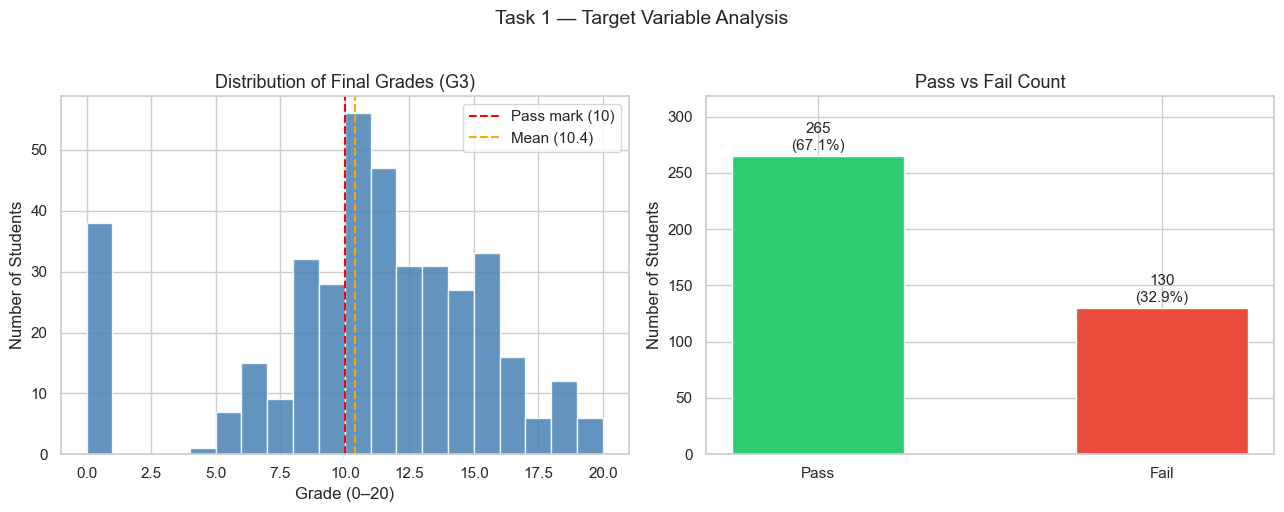

✅ Chart saved to images/charts/task1_grade_distribution.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: G3 histogram ───────────────────────────────────────────────────────
axes[0].hist(df['G3'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(x=10, color='red', linestyle='--', linewidth=1.5, label='Pass mark (10)')
axes[0].axvline(x=df['G3'].mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Mean ({df["G3"].mean():.1f})')
axes[0].set_title('Distribution of Final Grades (G3)')
axes[0].set_xlabel('Grade (0–20)')
axes[0].set_ylabel('Number of Students')
axes[0].legend()

# ── Right: Pass/Fail bar ─────────────────────────────────────────────────────
labels = ['Pass', 'Fail']
counts = [pass_count, fail_count]
colors = ['#2ecc71', '#e74c3c']
bars = axes[1].bar(labels, counts, color=colors, edgecolor='white', width=0.5)
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{count}\n({count/total*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11)
axes[1].set_title('Pass vs Fail Count')
axes[1].set_ylabel('Number of Students')
axes[1].set_ylim(0, max(counts) * 1.2)

plt.suptitle('Task 1 — Target Variable Analysis', fontsize=14, y=1.02)
plt.tight_layout()

# Save to images folder
os.makedirs('../images/charts', exist_ok=True)
plt.savefig('../images/charts/task1_grade_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved to images/charts/task1_grade_distribution.png')

## Cell 12 — Column Dictionary (Data Documentation)

A real data scientist always documents what each column means.
This becomes part of your final report and shows the reviewer you
actually understood the dataset — not just ran some code.

In [25]:
col_descriptions = {
    # ── Demographics ────────────────────────────────────────────────────────
    'school'    : 'Student school  | GP = Gabriel Pereira, MS = Mousinho da Silveira',
    'sex'       : 'Student sex     | F = female, M = male',
    'age'       : 'Student age     | 15 to 22 years',
    'address'   : 'Home address    | U = urban, R = rural',
    'famsize'   : 'Family size     | LE3 = ≤3 members, GT3 = >3 members',
    'Pstatus'   : 'Parents status  | T = together, A = apart',
    # ── Parent background ────────────────────────────────────────────────────
    'Medu'      : 'Mother education| 0=none, 1=primary, 2=middle, 3=secondary, 4=higher',
    'Fedu'      : 'Father education| 0=none, 1=primary, 2=middle, 3=secondary, 4=higher',
    'Mjob'      : 'Mother job      | teacher, health, services, at_home, other',
    'Fjob'      : 'Father job      | teacher, health, services, at_home, other',
    # ── School info ──────────────────────────────────────────────────────────
    'reason'    : 'School choice   | home, reputation, course, other',
    'guardian'  : 'Student guardian| mother, father, other',
    'traveltime': 'Travel time     | 1=<15min, 2=15-30min, 3=30-60min, 4=>60min',
    'studytime' : 'Study time/week | 1=<2hr, 2=2-5hr, 3=5-10hr, 4=>10hr',
    'failures'  : 'Past failures   | 0, 1, 2, or 3 classes failed before',
    # ── Support systems ──────────────────────────────────────────────────────
    'schoolsup' : 'School support  | Extra educational support (yes/no)',
    'famsup'    : 'Family support  | Family educational support (yes/no)',
    'paid'      : 'Paid classes    | Extra paid classes in subject (yes/no)',
    'activities': 'Activities      | Extra-curricular activities (yes/no)',
    'nursery'   : 'Nursery school  | Attended nursery school (yes/no)',
    'higher'    : 'Higher education| Wants to pursue higher education (yes/no)',
    'internet'  : 'Internet access | Internet at home (yes/no)',
    'romantic'  : 'Relationship    | In a romantic relationship (yes/no)',
    # ── Lifestyle ────────────────────────────────────────────────────────────
    'famrel'    : 'Family relation | Quality 1=very bad to 5=excellent',
    'freetime'  : 'Free time       | After school free time 1=very low to 5=very high',
    'goout'     : 'Going out       | Going out with friends 1=very low to 5=very high',
    'Dalc'      : 'Workday alcohol | Consumption 1=very low to 5=very high',
    'Walc'      : 'Weekend alcohol | Consumption 1=very low to 5=very high',
    'health'    : 'Health status   | 1=very bad to 5=very good',
    'absences'  : 'School absences | Number of absences (0–93)',
    # ── Grades (target) ──────────────────────────────────────────────────────
    'G1'        : 'Period 1 grade  | First term grade (0–20)',
    'G2'        : 'Period 2 grade  | Second term grade (0–20)',
    'G3'        : '⭐ FINAL GRADE  | Final grade TARGET (0–20)',
    'pass_fail' : '⭐ MODEL TARGET | 1 = Pass (G3≥10), 0 = Fail (G3<10)  [added by us]',
}

print(f'{'Column':<12}  {'Category':<22}  {'Description'}')
print('─' * 75)
for col, desc in col_descriptions.items():
    category, description = desc.split('|')
    print(f'{col:<12}  {category.strip():<22}  {description.strip()}')

Column        Category                Description
───────────────────────────────────────────────────────────────────────────
school        Student school          GP = Gabriel Pereira, MS = Mousinho da Silveira
sex           Student sex             F = female, M = male
age           Student age             15 to 22 years
address       Home address            U = urban, R = rural
famsize       Family size             LE3 = ≤3 members, GT3 = >3 members
Pstatus       Parents status          T = together, A = apart
Medu          Mother education        0=none, 1=primary, 2=middle, 3=secondary, 4=higher
Fedu          Father education        0=none, 1=primary, 2=middle, 3=secondary, 4=higher
Mjob          Mother job              teacher, health, services, at_home, other
Fjob          Father job              teacher, health, services, at_home, other
reason        School choice           home, reputation, course, other
guardian      Student guardian        mother, father, other
traveltime    

## Cell 13 — Task 1 Summary

Every task should end with a written summary of what you found.
This is what separates a data scientist from someone who just ran code.

In [29]:
print('=' * 65)
print('TASK 1 SUMMARY — Data Collection & Dataset Understanding')
print('=' * 65)

print(f'''
Dataset       : UCI Student Performance (Mathematics)
Source        : student-mat.csv
Shape         : {df.shape[0]} rows × {df.shape[1]} columns (including pass_fail)

Column types
  Numerical   : {len(num_cols)} columns  (grades, age, study time, etc.)
  Categorical : {len(cat_cols)} columns  (school, sex, job, yes/no fields)

Data quality
  Missing values : {df.isnull().sum().sum()} (none — dataset is clean)
  Duplicates     : {df.duplicated().sum()} (none)

Target variable
  G3 range    : {df['G3'].min()} – {df['G3'].max()}  (out of 20)
  G3 mean     : {df['G3'].mean():.2f}
  Pass rate   : {pass_count}/{total} = {pass_count/total*100:.1f}%
  Fail rate   : {fail_count}/{total} = {fail_count/total*100:.1f}%

Key observations
  1. Dataset is well-structured with no missing values.
  2. Strong class imbalance — far more passes than fails.
     This must be handled carefully during model building.
  3. Grades G1 and G2 will likely be strong predictors of G3.
  4. Lifestyle factors (Dalc, Walc, goout) may show interesting
     correlations with academic performance.
  5. Categorical columns need encoding before modelling.

Next step : Task 2 — Data Cleaning & Preprocessing
''')

print('=' * 65)

TASK 1 SUMMARY — Data Collection & Dataset Understanding

Dataset       : UCI Student Performance (Mathematics)
Source        : student-mat.csv
Shape         : 395 rows × 34 columns (including pass_fail)

Column types
  Numerical   : 16 columns  (grades, age, study time, etc.)
  Categorical : 17 columns  (school, sex, job, yes/no fields)

Data quality
  Missing values : 0 (none — dataset is clean)
  Duplicates     : 0 (none)

Target variable
  G3 range    : 0 – 20  (out of 20)
  G3 mean     : 10.42
  Pass rate   : 265/395 = 67.1%
  Fail rate   : 130/395 = 32.9%

Key observations
  1. Dataset is well-structured with no missing values.
  2. Strong class imbalance — far more passes than fails.
     This must be handled carefully during model building.
  3. Grades G1 and G2 will likely be strong predictors of G3.
  4. Lifestyle factors (Dalc, Walc, goout) may show interesting
     correlations with academic performance.
  5. Categorical columns need encoding before modelling.

Next step : 

---
**Task 1 complete.** ✅

The dataset is loaded, explored, and fully understood. All 33 columns are documented, the target variable is defined, and we have a clear plan for the next task.

→ Proceed to **Task 2: Data Cleaning & Preprocessing**